In [1]:
import altitude_helper
from altitude_helper import *
import skymap_data_helper

import importlib
importlib.reload(altitude_helper)


<module 'altitude_helper' from '/home/molidae/Desktop/berkeley/ssl/altitude_helper.py'>

In [2]:
#load an hour of data
site_yknf = 'yknf'
site_fsmi = 'fsmi'
date = datetime(2024,8,30)
hour = 5 #this is in UT

rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!
fsmi_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_fsmi, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav
Skymap file:
rgb_skymap_fsmi_20240808-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_fsmi_20240808-%2B_v01.sav


In [34]:
h_target = 200000 

lat_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
lon_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]

full_yknf_lat110 = np.array(yknf_rgb_asi_ds.lat_110)
full_yknf_lon110 = np.array(yknf_rgb_asi_ds.lon_110)
yknf_110_mask = np.isnan(full_yknf_lat110) | np.isnan(full_yknf_lon110) # apply this mask to all frames across all elevations for YKNF


print(full_yknf_lat110.shape)

lat_fsmi = fsmi_rgb_asi_ds.attrs["site_latitude"]
lon_fsmi = fsmi_rgb_asi_ds.attrs["site_longitude"]
full_elevation_fsmi = fsmi_rgb_asi_ds["elevation"]
full_azimuth_fsmi = fsmi_rgb_asi_ds["azimuth"]

full_fsmi_lat110 = np.array(fsmi_rgb_asi_ds.lat_110)
full_fsmi_lon110 = np.array(fsmi_rgb_asi_ds.lon_110)
fsmi_110_mask = np.isnan(full_fsmi_lat110) | np.isnan(full_fsmi_lon110) # apply this mask to all frames across all elevations for YKNF


yknf_lat_110_proj, yknf_lon_110_proj = project_lat_lon(full_azimuth_yknf, 
                                                     full_elevation_yknf, 
                                                     lat_yknf, 
                                                     lon_yknf, 
                                                     h_target, 
                                                     yknf_110_mask)

fsmi_lat_110_proj, fsmi_lon_110_proj = project_lat_lon(full_azimuth_fsmi, 
                                                     full_elevation_fsmi, 
                                                     lat_fsmi, 
                                                     lon_fsmi, 
                                                     h_target, 
                                                     fsmi_110_mask)


(480, 553)


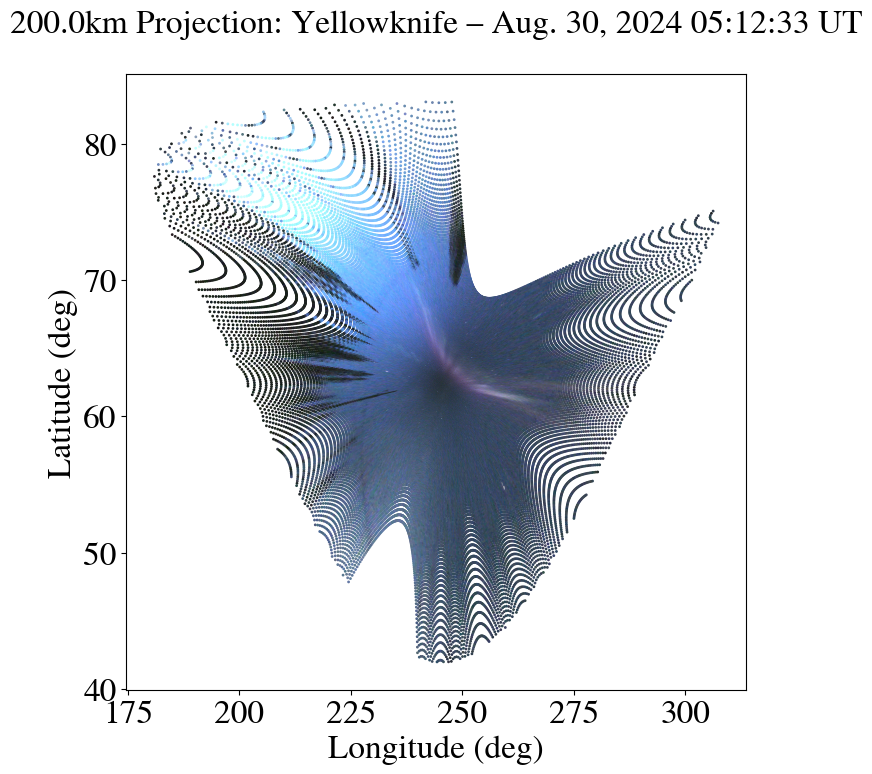

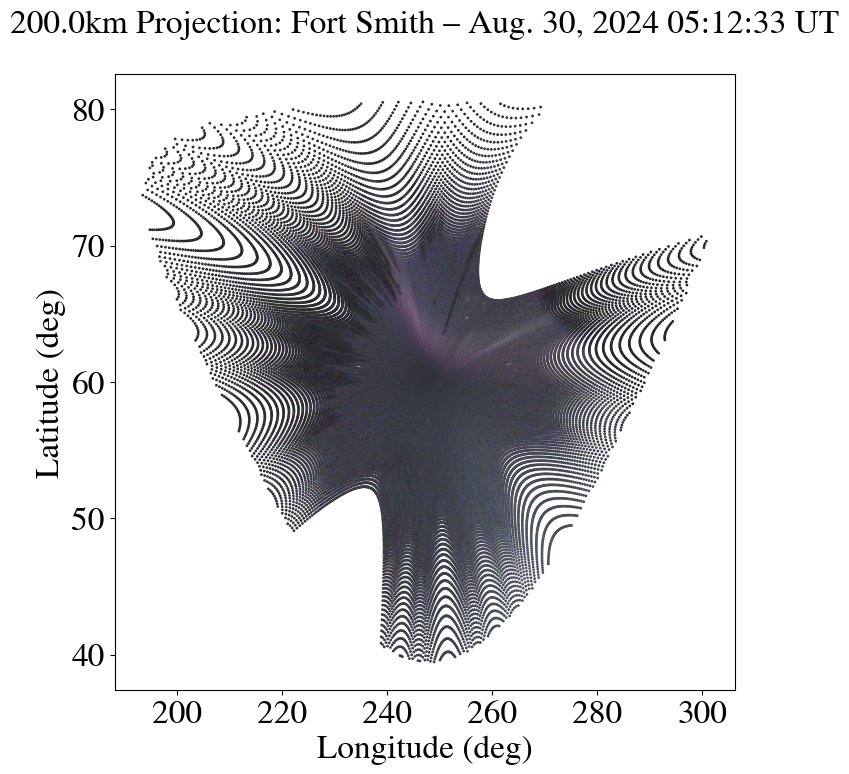

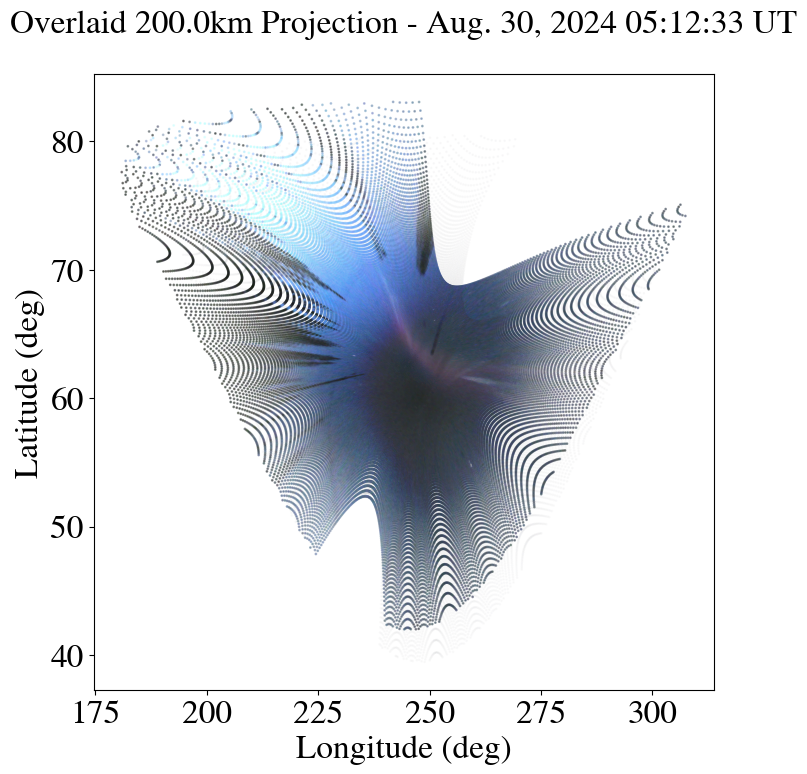

In [35]:
time_index = 251 # 5:10 UTC
site_name_yknf = "Yellowknife" 
site_name_fsmi = "Fort Smith" 

yknf_rgb, fsmi_rgb = plot_lat_lon(yknf_rgb_asi_ds, 
                                 fsmi_rgb_asi_ds, 
                                 time_index, 
                                 site_name_yknf, 
                                 site_name_fsmi, 
                                 yknf_lat_110_proj, 
                                 yknf_lon_110_proj, 
                                 fsmi_lat_110_proj, 
                                 fsmi_lon_110_proj,
                                 h_target)

## Interpolation (Linear)
1. define a common grid over which to perform the interpolation --> this common grid is based on the maximum and minimum latitude/longitude BEFORE masking
- get the overlapping area
3. interpolate the pixel intensities from both cameras over this entire grid
4. mask out the aurora overlap pixels --> do a quick and dirty version first, then clean it up (make it flexible enough to be run on all time)
5. calculate the similarity between the interpolated pixels, and do some overall metric to see how things are lining up
- try MSE

In [36]:
from scipy.ndimage import gaussian_filter
from skimage.filters import threshold_local
from skimage.morphology import skeletonize, remove_small_objects
from skimage.filters import frangi
import cv2 # for histogram equalization 

def masking(intensity):
    ''' 
    Isolates the auroral structure; accounting for large white patches in the background.
    Applies background filter (removing large-scale variations), local thresholding (patching), smoothing (removing stars)

    Parameters:
        intensity = 2D array of pixel intensities in grayscale (typically after interpolation)

    Returns:
        final_mask = final masked used, helpful for visualization
        masked_intensity = 2D array of pixel intensities after masking 
        
    '''

    # convert to cv2 array 
    # cv2.imwrite('intensity.png', intensity) # refactor so not saving a png each time masking 
    # intensity_cv2 = cv2.imread('intensity.png', cv2.IMREAD_GRAYSCALE)

    # # handling nongreyscale exceptions 
    # if(img.channels() == 3){
    #     cv2.cvtColor(intensity, gray, CV_BGR2GRAY);
    # }
    # else if(img.channels() == 4){
    #     cv2.cvtColor(img, gray, CV_BGRA2GRAY);
    # }
    # else{       
    #     gray = img;
    # }
    
    # histogram equalization (increases the contrast of the image)
    # equalized = cv2.equalizeHist(intensity)
    # compare_eq = np.hstack((intensity, equalized))
    # cv2.imwrite('compare_eq.png')
    
    # background subtraction
    sigma_bg = 20 # std dev for gaussian kernel 
    background = gaussian_filter(intensity, sigma=sigma_bg)
    img_background_removed = intensity - background 

    print(f"after background sub: {img_background_removed.shape}")

    # smoothing
    smoothed = gaussian_filter(img_background_removed, sigma=0.5)  # sigma=1 --> small smoothing, merge aurora pixels
    print(f"after smooth: {smoothed.shape}")
    
    # frangi filter --> helps for thin, elongated structures (erased too much)
    # frangi_filter = frangi(smoothed)
    
    # local thresholding --> replaced by frangi
    blocksize = 61 # local patch size
    offset = 0
    threshold_mask = smoothed > threshold_local(smoothed, blocksize, offset=offset)
    #img_thresholded = np.where(threshold_mask, img_background_removed, np.nan)

    # preserving elongated thin objects --> erased too much
    # skeleton = skeletonize(threshold_mask)
    # clean_mask = remove_small_objects(skeleton, min_size=5)

    

    # mask = frangi_filter > 0.1
    # final_mask = remove_small_objects(mask, min_size=5)
    final_mask = threshold_mask
    masked_intensity = np.where(final_mask, intensity, np.nan)
    
    return final_mask, masked_intensity  
    

In [37]:
from scipy.interpolate import griddata
from scipy.stats import pearsonr
from PIL import Image

# grid boundaries --> intersection of the fields of view for YKNF and FSMI
lat_min = max(np.nanmin(yknf_lat_110_proj), np.nanmin(fsmi_lat_110_proj))
lon_min = max(np.nanmin(yknf_lon_110_proj), np.nanmin(fsmi_lon_110_proj))
lat_max = min(np.nanmax(yknf_lat_110_proj), np.nanmax(fsmi_lat_110_proj))
lon_max = min(np.nanmax(yknf_lon_110_proj), np.nanmax(fsmi_lon_110_proj))



# grid --> need to make this more sophisticated, bc some distortion from using the dims of az/el grid
n_lat = 500
n_lon = 500
lat_grid = np.linspace(lat_min, lat_max, n_lat)
lon_grid = np.linspace(lon_min, lon_max, n_lon)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

# enhance color channels to make purple/green brighter when converted to greyscale
yknf_enhanced = yknf_rgb.copy()
yknf_enhanced[:,:,1] = np.clip(yknf_enhanced[:,:,1]*1.5, 0, 255) # green channel
yknf_enhanced[:,:,0] = np.clip(yknf_enhanced[:,:,0]*1.2, 0, 255) # red channel
yknf_enhanced[:,:,2] = np.clip(yknf_enhanced[:,:,2]*1.2, 0, 255) # blue channel
fsmi_enhanced = fsmi_rgb.copy()
fsmi_enhanced[:,:,1] = np.clip(fsmi_enhanced[:,:,1]*1.5, 0, 255) # green channel
fsmi_enhanced[:,:,0] = np.clip(fsmi_enhanced[:,:,0]*1.2, 0, 255) # red channel
fsmi_enhanced[:,:,2] = np.clip(fsmi_enhanced[:,:,2]*1.2, 0, 255) # blue channel

# convert to greyscale
yknf_img = Image.fromarray(yknf_enhanced)
yknf_grayscale = yknf_img.convert('L')
yknf_grayscale_arr = np.array(yknf_grayscale)
fsmi_img = Image.fromarray(fsmi_enhanced)
fsmi_grayscale = fsmi_img.convert('L')
fsmi_grayscale_arr = np.array(fsmi_grayscale)

# flatten yknf and fsmi projected + grayscale
yknf_flattened_points = np.column_stack((yknf_lon_110_proj.flatten(), yknf_lat_110_proj.flatten())) # (N,2) pairs of (lat, lon)
print(f"yknf flattened w/ col stack shape: {yknf_flattened_points.shape}")
yknf_grayscale_flattened_values = yknf_grayscale_arr.flatten()
fsmi_flattened_points = np.column_stack((fsmi_lon_110_proj.flatten(), fsmi_lat_110_proj.flatten()))
fsmi_grayscale_flattened_values = fsmi_grayscale_arr.flatten()

# clip YKNF and FSMI to intersection before interpolation
# intersection_mask = (yknf_flattened_points[:,0] >= lon_min) & (yknf_flattened_points[:,0] <= lon_max) & \
#        (yknf_flattened_points[:,1] >= lat_min) & (yknf_flattened_points[:,1] <= lat_max)
# yknf_points_clipped = yknf_flattened_points[intersection_mask]
# yknf_values_clipped = yknf_grayscale_flattened_values[intersection_mask]
# fsmi_points_clipped = fsmi_flattened_points[intersection_mask]
# fsmi_values_clipped = fsmi_grayscale_flattened_values[intersection_mask]

# remove NaNs
yknf_nan_mask = (np.isfinite(yknf_flattened_points).all(axis=1) & np.isfinite(yknf_grayscale_flattened_values))
fsmi_nan_mask = (np.isfinite(fsmi_flattened_points).all(axis=1) & np.isfinite(fsmi_grayscale_flattened_values))

yknf_points_clean = yknf_flattened_points[yknf_nan_mask]
print(f"yknf points clean shape: {yknf_points_clean.shape}")
yknf_values_clean = yknf_grayscale_flattened_values[yknf_nan_mask]
fsmi_points_clean = fsmi_flattened_points[fsmi_nan_mask]
fsmi_values_clean = fsmi_grayscale_flattened_values[fsmi_nan_mask]

# interpolation 
yknf_interp_intensity = griddata(yknf_points_clean, yknf_values_clean, (lon_mesh, lat_mesh), method='linear')
print(f"yknf_interp_intensity: {yknf_interp_intensity.shape}")
fsmi_interp_intensity = griddata(fsmi_points_clean, fsmi_values_clean, (lon_mesh, lat_mesh), method='linear')

# correlation between the interpolated yknf and fsmi values (need to flatten and remove NaNs for pearson)
# yknf_interp_intensity_flat = yknf_interp_intensity.flatten()
# fsmi_interp_intensity_flat = fsmi_interp_intensity.flatten()
# valid = ~np.isnan(yknf_interp_intensity_flat) & ~np.isnan(fsmi_interp_intensity_flat)
# yknf_interp_valid = yknf_interp_intensity_flat[valid]
# fsmi_interp_valid = fsmi_interp_intensity_flat[valid]

# masking out non-auroral background
# yknf_threshold = np.nanpercentile(yknf_interp_intensity, 90)
# fsmi_threshold = np.nanpercentile(fsmi_interp_intensity, 90)
# yknf_aurora_mask = yknf_interp_intensity > yknf_threshold
# fsmi_aurora_mask = fsmi_interp_intensity > fsmi_threshold

# # get only auroras
# yknf_interp_aurora = np.where(yknf_aurora_mask, yknf_interp_intensity, np.nan)
# fsmi_interp_aurora = np.where(fsmi_aurora_mask, fsmi_interp_intensity, np.nan)

# yknf_interp_aurora_flat = yknf_interp_aurora.flatten()
# fsmi_interp_aurora_flat = fsmi_interp_aurora.flatten()

# masking
yknf_final_mask, yknf_aurora = masking(yknf_interp_intensity)
fsmi_final_mask, fsmi_aurora = masking(fsmi_interp_intensity)


# remove NaNs
valid = ~np.isnan(yknf_aurora) & ~np.isnan(fsmi_aurora)
yknf_interp_valid = yknf_aurora[valid]
fsmi_interp_valid = fsmi_aurora[valid]

corr, _ = pearsonr(yknf_interp_valid, fsmi_interp_valid)
print("YKNF and FSMI intensity correlation:", corr)


yknf flattened w/ col stack shape: (265440, 2)
yknf points clean shape: (202281, 2)
yknf_interp_intensity: (500, 500)
after background sub: (500, 500)
after smooth: (500, 500)
after background sub: (500, 500)
after smooth: (500, 500)
YKNF and FSMI intensity correlation: -0.11456007752993132


In [21]:
yknf_img.show()
fsmi_img.show()

after background sub: (500, 500)
after smooth: (500, 500)
after background sub: (500, 500)
after smooth: (500, 500)
yknf_masked_intesnity shape: (500, 500)
valid: (500, 500)
(500, 500)


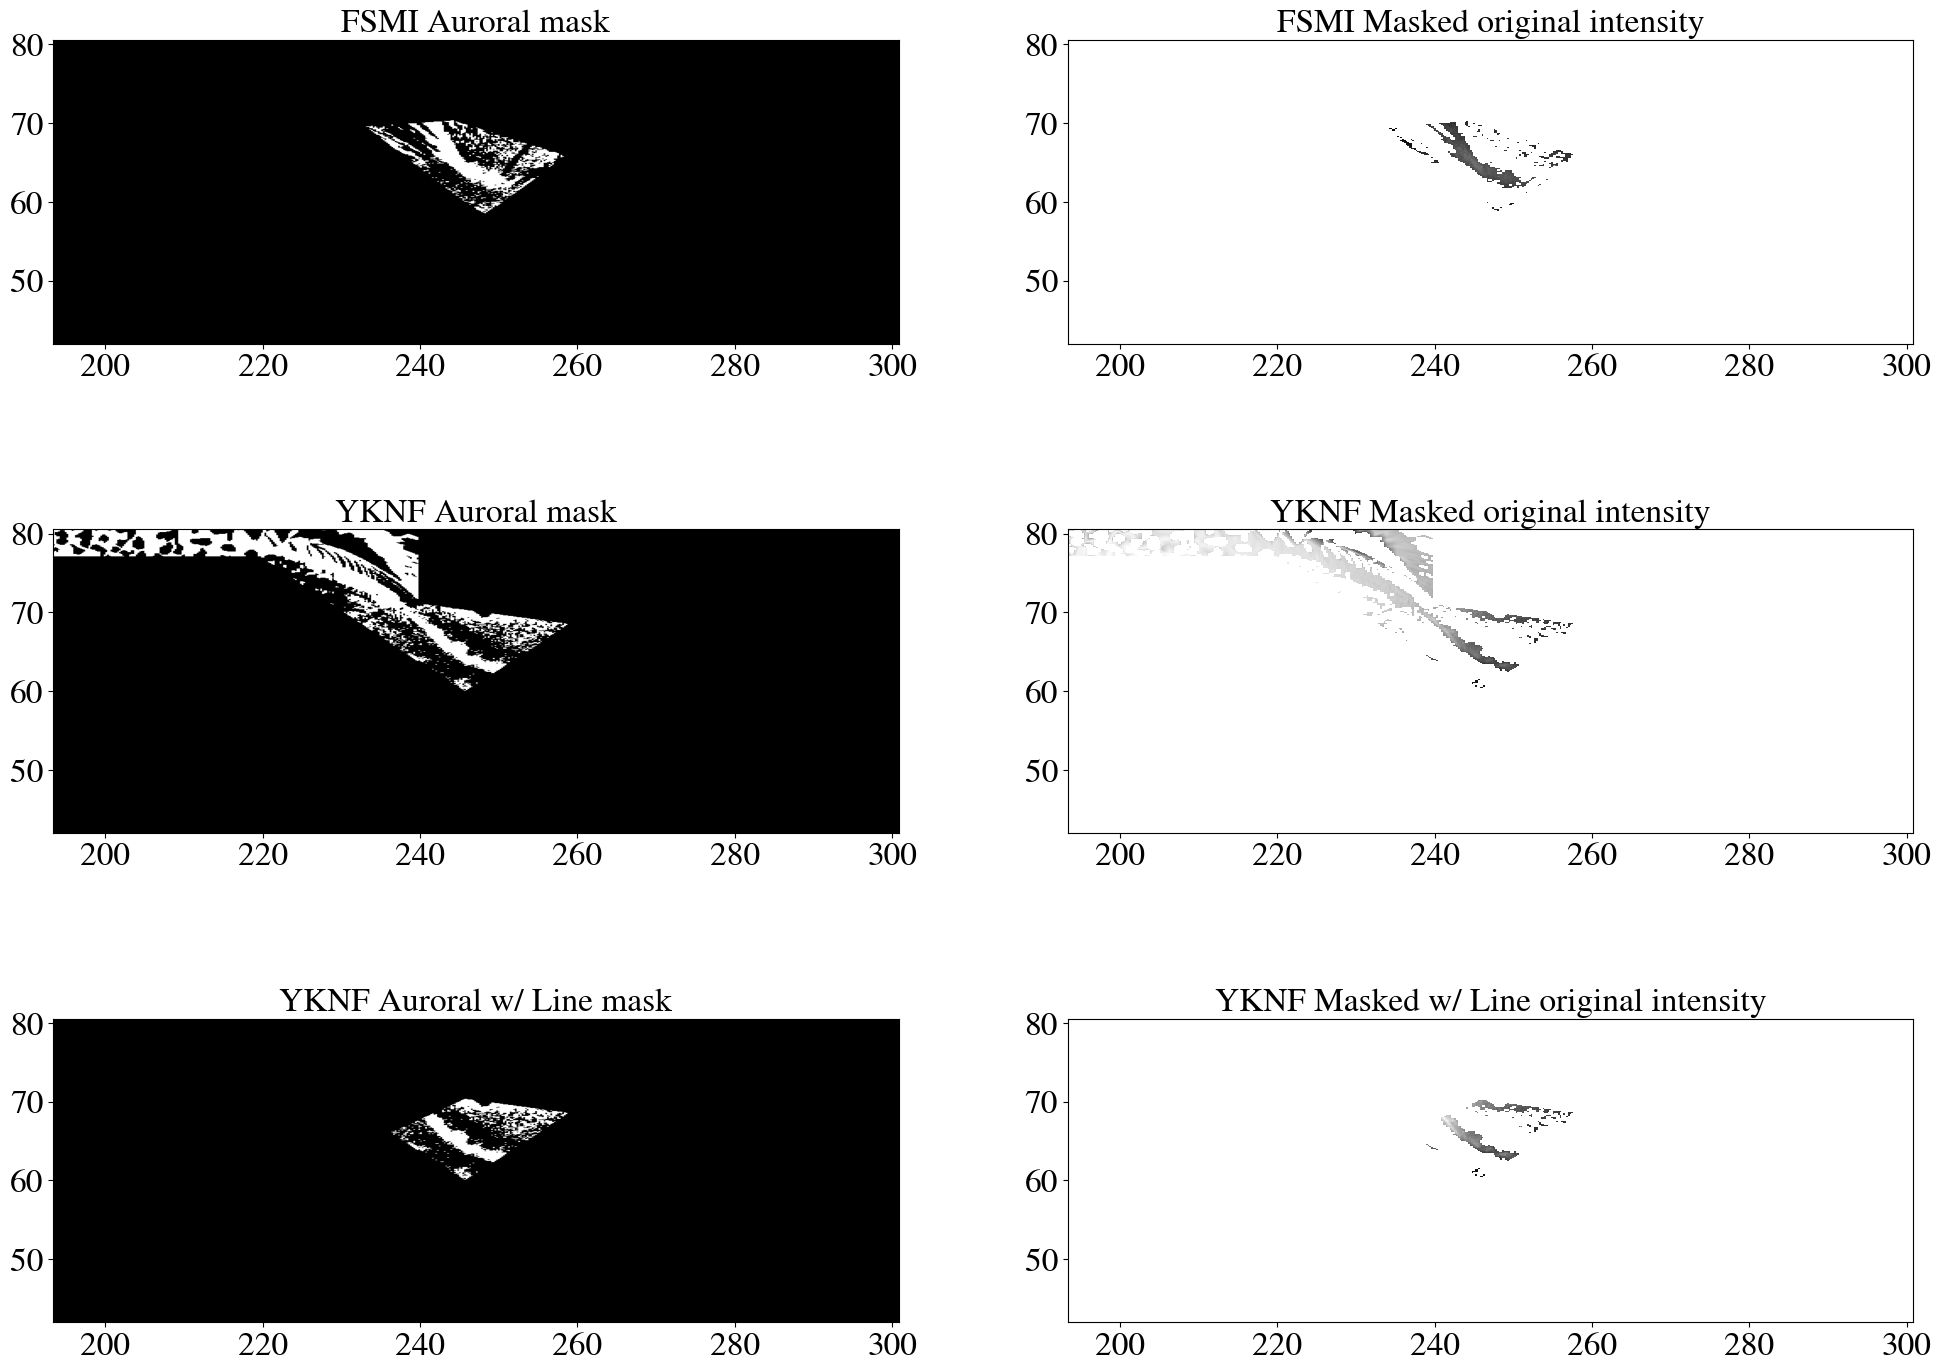

In [38]:
fsmi_final_mask, fsmi_masked_intensity = masking(fsmi_interp_intensity)
yknf_final_mask, yknf_masked_intensity = masking(yknf_interp_intensity)

print(f"yknf_masked_intesnity shape: {yknf_masked_intensity.shape}")

valid = ~np.isnan(fsmi_masked_intensity) & ~np.isnan(yknf_masked_intensity)
print(f"valid: {valid.shape}")
yknf_interp_valid = np.where(valid, yknf_masked_intensity, np.nan)
fsmi_interp_valid = np.where(valid, fsmi_masked_intensity, np.nan)

print(yknf_interp_valid.shape)

#corr, _ = pearsonr(yknf_interp_valid, fsmi_interp_valid)
#print("YKNF and FSMI intensity correlation:", corr)

## manually remove the extra area on the top for YKNF --> need to figure out how to do this more robustly
## clipping based on the corners  
## (234, 65), (245, 70) --> y-70 = 0.4545(x - 245) --> y = 0.4545(x-245) + 70 
# slope = 0.4545
num_points = 100
yknf_line_mask = lat_mesh < (0.4545 * (lon_mesh - 245) + 70)
yknf_total_mask = yknf_line_mask & yknf_final_mask
yknf_line_masked_intensity = np.where(yknf_line_mask, yknf_masked_intensity, np.nan)


plt.figure(figsize=(24,18))

# fsmi mask 
plt.subplot(3,2,1)
plt.imshow(fsmi_final_mask, cmap='gray', origin='lower',
           extent=(lon_min, lon_max, lat_min, lat_max))
plt.title("FSMI Auroral mask")

plt.subplot(3,2,2)
plt.imshow(fsmi_masked_intensity, cmap='gray', origin='lower',
           extent=(lon_min, lon_max, lat_min, lat_max))
plt.title("FSMI Masked original intensity")

# yknf mask
plt.subplot(3,2,3)
plt.imshow(yknf_final_mask, cmap='gray', origin='lower',
           extent=(lon_min, lon_max, lat_min, lat_max))
plt.title("YKNF Auroral mask")

plt.subplot(3,2,4)
plt.imshow(yknf_masked_intensity, cmap='gray', origin='lower',
           extent=(lon_min, lon_max, lat_min, lat_max))
plt.title("YKNF Masked original intensity")

# yknf with line mask
plt.subplot(3,2,5)
plt.imshow(yknf_total_mask, cmap='gray', origin='lower',
           extent=(lon_min, lon_max, lat_min, lat_max))
plt.title("YKNF Auroral w/ Line mask")

plt.subplot(3,2,6)
plt.imshow(yknf_line_masked_intensity, cmap='gray', origin='lower',
           extent=(lon_min, lon_max, lat_min, lat_max))
plt.title("YKNF Masked w/ Line original intensity")


plt.show()


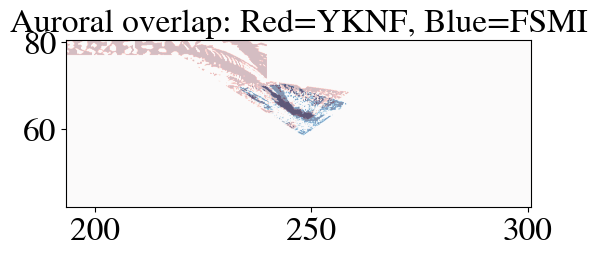

In [39]:

plt.figure(figsize=(6,6))
plt.imshow(yknf_final_mask, alpha=0.5, cmap='Reds', origin='lower', extent=(lon_min, lon_max, lat_min, lat_max))
plt.imshow(fsmi_final_mask, alpha=0.5, cmap='Blues', origin='lower', extent=(lon_min, lon_max, lat_min, lat_max))
plt.title("Auroral overlap: Red=YKNF, Blue=FSMI")
plt.show()


In [40]:
# correlation after strict line cutoff 
valid = ~np.isnan(yknf_line_masked_intensity) & ~np.isnan(fsmi_aurora)
yknf_interp_line_valid = yknf_line_masked_intensity[valid]
fsmi_interp_line_valid = fsmi_aurora[valid]

corr_line, _ = pearsonr(yknf_interp_line_valid, fsmi_interp_line_valid)
print("YKNF and FSMI intensity correlation after line cutoff:", corr_line)


YKNF and FSMI intensity correlation after line cutoff: 0.29336377160591687


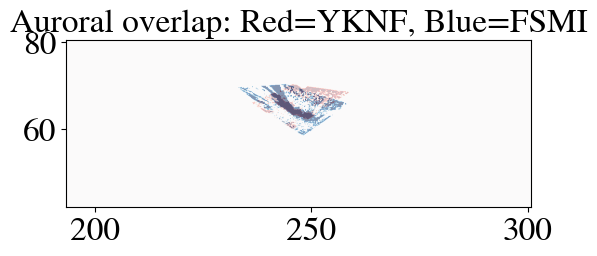

In [41]:
# after strict cutoff 
plt.figure(figsize=(6,6))
plt.imshow(yknf_total_mask, alpha=0.5, cmap='Reds', origin='lower', extent=(lon_min, lon_max, lat_min, lat_max))
plt.imshow(fsmi_final_mask, alpha=0.5, cmap='Blues', origin='lower', extent=(lon_min, lon_max, lat_min, lat_max))
plt.title("Auroral overlap: Red=YKNF, Blue=FSMI")
plt.show()

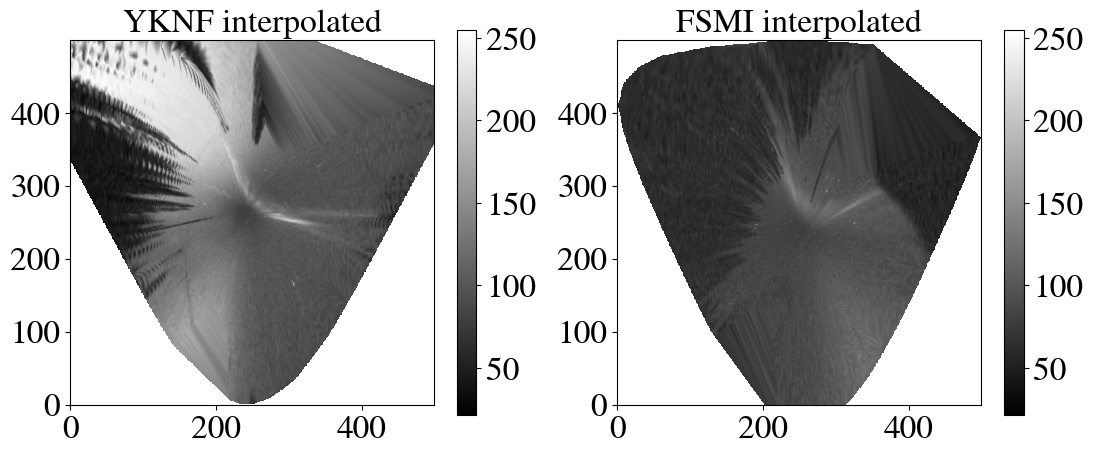

In [42]:
vmin = min(np.nanmin(yknf_interp_intensity), np.nanmin(fsmi_interp_intensity))
vmax = max(np.nanmax(yknf_interp_intensity), np.nanmax(fsmi_interp_intensity))

plt.figure(figsize=(20,5))

plt.subplot(1,3,1)
plt.imshow(yknf_interp_intensity, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
plt.title("YKNF interpolated")
plt.colorbar()

plt.subplot(1,3,2)
plt.imshow(fsmi_interp_intensity, cmap='gray', origin='lower', vmin=vmin, vmax=vmax)
plt.title("FSMI interpolated")
plt.colorbar()


In [43]:
print(lat_min, lat_max, lon_min, lon_max)

42.000741516778305 80.54197434850158 193.37946983739386 300.79458704390163


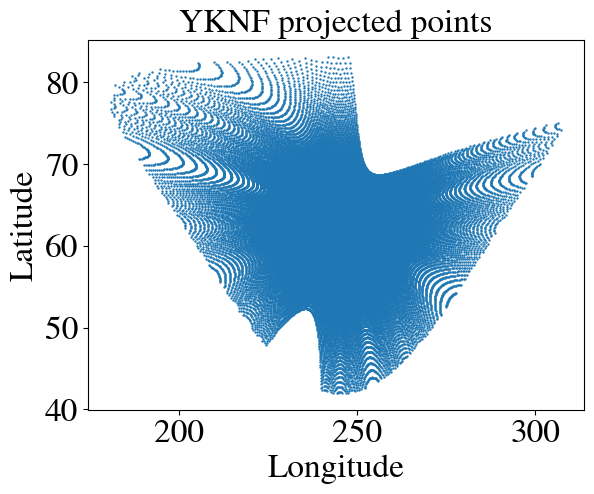

In [44]:
plt.scatter(yknf_points_clean[:,0], yknf_points_clean[:,1], s=0.5)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("YKNF projected points")
plt.show()

In [15]:
print("YKNF lat min/max:", np.nanmin(yknf_lat_110_proj), np.nanmax(yknf_lat_110_proj))
print("YKNF lon min/max:", np.nanmin(yknf_lon_110_proj), np.nanmax(yknf_lon_110_proj))
print("FSMI lat min/max:", np.nanmin(fsmi_lat_110_proj), np.nanmax(fsmi_lat_110_proj))
print("FSMI lon min/max:", np.nanmin(fsmi_lon_110_proj), np.nanmax(fsmi_lon_110_proj))
## maybe try not interpolating to the same exact overlapping space? 

YKNF lat min/max: 47.13051810505199 77.93189655015098
YKNF lon min/max: 206.27571863156388 284.95405127127765
FSMI lat min/max: 44.6020074892793 75.41300866207199
FSMI lon min/max: 212.98422249531743 283.23093469755713


## Linear Fitting
1. taking vertical slices in longitude for each of the regions in the YKNF and in the FSMI frames (getting spectral lines), fit gaussians to the brightness of each pixel in the slice
   - the peak of the gaussian is the brightest pixel in the vertical slice is, record the lat and lon that that pixel occurs at
   - repeat this for all the slices across YKNF and FSMI frames, then fit a line to all of these recorded (lat, lon) of brightest pixels
   - calculate how different the lines are in slope and in vetical distance from eachother
   - this works bc theoretically, STEVE should be a straight phenomenon, hence fitting a straight line to it

2. Steps
    - masking to get the bounds of the aurora --> won't all be the same brightness-- should be enough variation to fit a gaussian to it
    - pick out individuals columns (fixed longitude, varying latitude) from the masked pixels to get each gaussian fit
      - can do this for every single column, or every 3 columns, etc
      - have an 480x553 array of all of the intensities, but also need the corresponding latitude and longitude values 
    - use scipy.optimize.curve_fit to fit gaussian function (x-values = latitude, y-values = pixel intensities)
    - find the coordinates (lat, lon) of the peak of each gaussian, store in some array
    - fit a line through the coordinates of all of the peaks
    - repeat for for both yknf and fsmi, and calculate the difference / distance between their respective lines (ie in slope and in vertical distance) 


In [100]:
# convert original projections to greyscale
yknf_img = Image.fromarray(yknf_enhanced)
yknf_grayscale = yknf_img.convert('L')
yknf_grayscale_arr = np.array(yknf_grayscale)
fsmi_img = Image.fromarray(fsmi_enhanced)
fsmi_grayscale = fsmi_img.convert('L')
fsmi_grayscale_arr = np.array(fsmi_grayscale)

# masking on original projections (480, 553)
yknf_mask, yknf_masked = masking(yknf_grayscale_arr) 
fsmi_mask, fsmi_masked = masking(fsmi_grayscale_arr)
yknf_masked_flat = yknf_masked.flatten()
fsmi_masked_flat = fsmi_masked.flatten()


# bin by longitude

yknf_lat_flat = yknf_lat_110_proj.flatten()
yknf_lon_flat = yknf_lon_110_proj.flatten()
fsmi_lat_flat = fsmi_lat_110_proj.flatten()
fsmi_lon_flat = yknf_lon_110_proj.flatten()

# bins
yknf_lon_bins = np.linspace(np.nanmin(yknf_lon_flat), np.nanmax(yknf_lon_flat), 500)
fsmi_lon_bins = np.linspace(np.nanmin(fsmi_lon_flat), np.nanmax(fsmi_lon_flat), 500)

# loop through the longitude bins to get the slices of pixel intensities w/ varying latitudes
yknf_gaussian_results = []
yknf_sorted_intensity_arr = []
yknf_sorted_lat_arr = []
for i in range(len(yknf_lon_bins)-1):
    yknf_lon_mask = (yknf_lon_flat >= yknf_lon_bins[i]) & (yknf_lon_flat < yknf_lon_bins[i+1])
    if np.sum(yknf_lon_mask) < 20: # don't get slices / fit gaussians to those slices if there are less than 20 values 
        continue 
    yknf_lat_slice = yknf_lat_flat[yknf_lon_mask]
    yknf_intensity_slice = yknf_masked_flat[yknf_lon_mask]

    # sort the latitude and intensity values according to latitude 
    sort_idx = np.argsort(yknf_lat_slice)
    yknf_lat_sorted = yknf_lat_slice[sort_idx]
    yknf_intensity_sorted = yknf_intensity_slice[sort_idx]

    yknf_sorted_intensity_arr.append(yknf_intensity_sorted)
    yknf_sorted_lat_arr.append(yknf_lat_sorted)

    # parameters for gaussian 
    A0 = np.max(yknf_intensity_sorted) - np.min(yknf_intensity_sorted)
    mu0 = yknf_lat_sorted[np.argmax(yknf_intensity_sorted)]
    sigma0 = 0.5
    C0 = np.min(yknf_intensity_sorted)

    # fit gaussian, except when there are nan values 
    try:
        opt_params, _ = curve_fit(gaussian, yknf_lat_sorted, yknf_intensity_sorted, p0=[A0, mu0, sigma0, C0])
        yknf_gaussian_results.append((yknf_lon_bins[i], *opt_params))
        #print("entered here")
    except:
        yknf_gaussian_results.append((yknf_lon_bins[i], np.nan, np.nan, np.nan, np.nan)) # in case parameters weren't found (couldn't fit gaussian)
        #print("here!")

    

# loop through all of the columns
# count = 0
# for col in zip(*yknf_masked):
#     print(col)



after background sub: (480, 553)
after smooth: (480, 553)
after background sub: (480, 553)
after smooth: (480, 553)


[47. 39. 53. 44. 45. 51. 46. 39. 41. 48. 33. 47. 41. 66. 37. 44. nan nan
 nan nan]
[65.26039895 65.48940912 66.21231804 67.31539194 67.63060304 68.80502055
 70.55511592 70.60668704 70.66019538 70.71570632 70.77323987 70.832833
 72.43535888 73.45597773 73.74233038 75.00707349 77.21080347 77.31732206
 77.44333894 77.58949576]


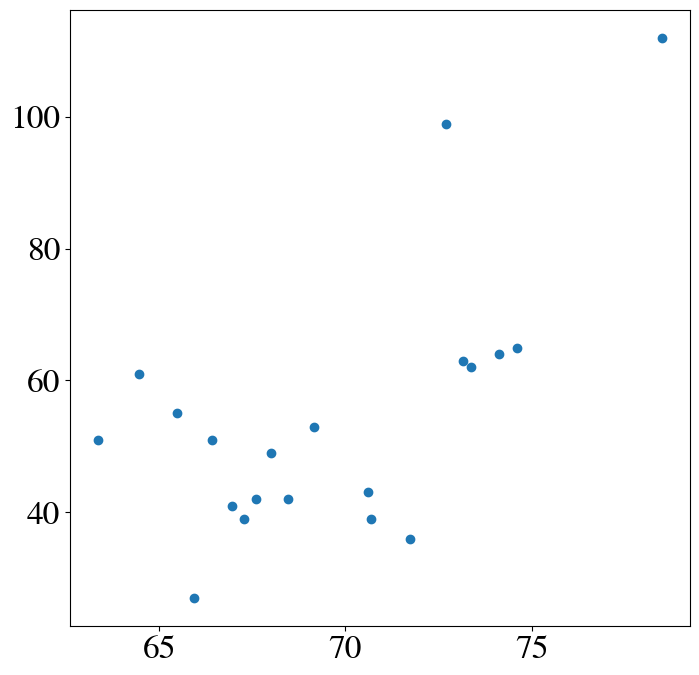

In [112]:
print(yknf_sorted_intensity_arr[0])
print(yknf_sorted_lat_arr[0])

plt_idx = 7
fig1, ax1 = plt.subplots(figsize=(8,8))
scat1 = ax1.scatter(yknf_sorted_lat_arr[plt_idx],yknf_sorted_intensity_arr[plt_idx])

In [102]:
yknf_gaussian_results

[(196.8985229153773, nan, nan, nan, nan),
 (199.43260993490225, nan, nan, nan, nan),
 (199.93942733880726, nan, nan, nan, nan),
 (200.69965344466473, nan, nan, nan, nan),
 (201.20647084856972, nan, nan, nan, nan),
 (202.72692306028472, nan, nan, nan, nan),
 (203.2337404641897, nan, nan, nan, nan),
 (203.4871491661422, nan, nan, nan, nan),
 (203.7405578680947, nan, nan, nan, nan),
 (203.99396657004718, nan, nan, nan, nan),
 (204.2473752719997, nan, nan, nan, nan),
 (204.50078397395217, nan, nan, nan, nan),
 (204.75419267590468, nan, nan, nan, nan),
 (205.00760137785716, nan, nan, nan, nan),
 (205.26101007980967, nan, nan, nan, nan),
 (205.51441878176217, nan, nan, nan, nan),
 (205.76782748371465, nan, nan, nan, nan),
 (206.02123618566716, nan, nan, nan, nan),
 (206.27464488761964, nan, nan, nan, nan),
 (206.52805358957215, nan, nan, nan, nan),
 (206.78146229152463, nan, nan, nan, nan),
 (207.03487099347714, nan, nan, nan, nan),
 (207.28827969542965, nan, nan, nan, nan),
 (207.5416883973

In [52]:
my_array = [[1, 2, 3],
            [4, 5, 6],
            [7, 8, 9]]

for column in zip(*my_array):
    print(column)

(1, 4, 7)
(2, 5, 8)
(3, 6, 9)


In [61]:

print(*yknf_lat_110_proj)[0])


nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan 83.06232077501753 82.39134550335726 81.7676932865591 81.18658334826603 80.64378424301376 80.13565705268569 79.65903213081857 79.21104840468635 78.7892443752077 78.39139716641814 78.01555819499566 77.65993756432242 77.32298606276353 77.00330436564504 76.69957172375325 76.41068620064759 76.1355741301125 75.87329389438752 75.62298099719891 75.3838660443403 75.15521

In [65]:
total_values = sum(len(row) for row in yknf_lat_110_proj)
target_value = 68.67
count = 0
for row in yknf_lat_110_proj:
    for element in row:
        if round(element, 2) == target_value:
            count += 1
print(count)



35
